# Partie 2  Analyse exploratoire des nouvelles covariables



## Nouvelles covariables étudiées
- **Climat** : `temp_mean_c`, `precip_mm`, `dewpoint_c`
- **Sol** : `soil_ph`, `soil_oc`, `soil_texture`
- **Topographie** : `elevation_m`, `landform_class`

# importation des bib nécessaires et plt pour la visualisation

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif, mutual_info_classif
from IPython.display import display

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Mapping

In [204]:
# =========================
# Mappings des codes
# =========================

label_mapping_ark = {
    1: "Corn",
    2: "Cotton",
    3: "Rice",
    5: "Soybeans",
    999: "Others"
}

label_mapping_clf = {69: "Grapes", 
                      3: "Rice", 
                      36: "Alfalfa",
                        75: "Almonds",
                          204: "Pistachios"
                          }

soil_texture_mapping = {
    1.0: "Clay",
    2.0: "Clay loam",
    4.0: "Loamy sand",
    5.0: "Sand",
    7.0: "Sandy clay loam",
    8.0: "Sandy loam",
    9.0: "Silt",
    10.0: "Silty clay"
}

landform_mapping = {
    11: "Peak/ridge (warm)",
    12: "Peak/ridge",
    21: "Upper slope (warm)",
    22: "Upper slope",
    24: "Upper slope (flat)",
    31: "Lower slope (warm)",
    32: "Lower slope",
    34: "Lower slope (flat)",
    41: "Valley",
    42: "Valley (narrow)"
}


## les colonnes utilisées

In [205]:
ARK_PATH = "ARKANSAS_FULL.csv"
CAL_PATH = "CALIFORNIA_FULL.csv"

NUM_COLS = [
    "temp_mean_c",
    "precip_mm",
    "dewpoint_c",
    "soil_ph",
    "soil_oc",
    "elevation_m"
]

CAT_COLS = [
    "soil_texture",
    "landform_class"
]

ALL_COVARIATES = NUM_COLS + CAT_COLS

##  Compréhension des données

In [206]:
# on affiche dataset et afficher la dimension

def load_dataset(csv_path, dataset_name):
    df = pd.read_csv(csv_path).copy()
    print("=" * 80)
    print(f"{dataset_name.upper()} — Chargement terminé")
    print("=" * 80)
    print("Dimensions :", df.shape)
    return df

# Vérifier que tt les clmn sont présentes 

def check_required_columns(df, dataset_name):
    required_cols = ["label"] + ALL_COVARIATES
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{dataset_name}: colonnes manquantes -> {missing}")
    print(f"{dataset_name}: toutes les colonnes attendues sont présentes.")


#pour afficher les info dd ataset

def show_basic_info(df, dataset_name):
    print("\n--- Aperçu général ---")
    print("Dimensions :", df.shape)

    print("\n--- Valeurs manquantes ---")
    display(df[["label"] + ALL_COVARIATES].isnull().sum().to_frame("missing_values"))

    print("\n--- Répartition des classes ---")
    class_counts = df["label"].value_counts().sort_index()
    display(class_counts.to_frame("count"))

    print("\n--- Statistiques descriptives des covariables numériques ---")
    display(df[NUM_COLS].describe().T)

    return class_counts


#pour graphe de la répartition des classes 

def plot_class_distribution(df, dataset_name):
    counts = df["label"].value_counts().sort_index()
    plt.figure(figsize=(7,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"{dataset_name} - Répartition des classes")
    plt.xlabel("Classe")
    plt.ylabel("Nombre d'échantillons")
    plt.tight_layout()
    plt.show()


#tracer l histogramme de chaque variable numerique

def plot_histograms(df, dataset_name):
    for col in NUM_COLS:
        plt.figure(figsize=(7,4))
        plt.hist(df[col].dropna(), bins=30)
        plt.title(f"{dataset_name} - Distribution de {col}")
        plt.xlabel(col)
        plt.ylabel("Fréquence")
        plt.tight_layout()
        plt.show()

#pour afficher la moyenne et l’écart-type de chaque variable par classe

def show_class_means_stds(df, dataset_name):
    print(f"\n--- {dataset_name} : moyennes par classe ---")
    display(df.groupby("label")[NUM_COLS].mean())

    print(f"\n--- {dataset_name} : écarts-types par classe ---")
    display(df.groupby("label")[NUM_COLS].std())


def plot_boxplots_by_class(df, dataset_name):
    for col in NUM_COLS:
        plt.figure(figsize=(9,4.8))
        df.boxplot(column=col, by="label", grid=False)
        plt.title(f"{dataset_name} - {col} par classe")
        plt.suptitle("")
        plt.xlabel("Classe")
        plt.ylabel(col)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

#pour calculer et afficher la matrice de corrélation des variables numériques

def correlation_analysis(df, dataset_name):
    corr = df[NUM_COLS].corr()

    plt.figure(figsize=(7, 5))
    plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(label="Corrélation")
    plt.xticks(range(len(NUM_COLS)), NUM_COLS, rotation=45, ha="right")
    plt.yticks(range(len(NUM_COLS)), NUM_COLS)
    plt.title(f"{dataset_name} - Matrice de corrélation")

    for i in range(len(NUM_COLS)):
        for j in range(len(NUM_COLS)):
            plt.text(
                j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center",
                color="black", fontsize=8
            )

    plt.tight_layout()
    plt.show()

    return corr

#analyse dees variables categorielles



def analyze_categorical_variables(df, dataset_name):
    df = df.copy()

    for col in CAT_COLS:
        if col == "soil_texture" and "soil_texture_name" in df.columns:
            col_to_use = "soil_texture_name"
        elif col == "landform_class" and "landform_name" in df.columns:
            col_to_use = "landform_name"
        else:
            col_to_use = col

        class_col = "label_name" if "label_name" in df.columns else "label"

        print(f"\n--- {dataset_name} : distribution de {col} ---")
        display(df[col_to_use].value_counts(dropna=False).sort_index().to_frame("count"))

        cross_tab = pd.crosstab(df[class_col], df[col_to_use])
        print(f"\n--- {dataset_name} : tableau croisé {class_col} x {col_to_use} ---")
        display(cross_tab)

        cross_tab.plot(kind="bar", stacked=True, figsize=(10,5))
        plt.title(f"{dataset_name} - Répartition de {col_to_use} selon les classes")
        plt.xlabel("Classe")
        plt.ylabel("Nombre")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()


#mesurer l’importance des variables avec ANOVA et Mutual Information

def feature_importance_analysis(df, dataset_name):
    le = LabelEncoder()
    y = le.fit_transform(df["label"])

    X_num = df[NUM_COLS].values
    f_scores, p_values = f_classif(X_num, y)

    anova_df = pd.DataFrame({
        "feature": NUM_COLS,
        "f_score": f_scores,
        "p_value": p_values
    }).sort_values("f_score", ascending=False)

    print(f"\n--- {dataset_name} : ANOVA F-score ---")
    display(anova_df)

    X_all = pd.get_dummies(df[ALL_COVARIATES], columns=CAT_COLS, drop_first=False)
    mi = mutual_info_classif(X_all, y, random_state=42)

    mi_df = pd.DataFrame({
        "feature": X_all.columns,
        "mutual_info": mi
    }).sort_values("mutual_info", ascending=False)

    print(f"\n--- {dataset_name} : Mutual Information ---")
    display(mi_df.head(20))

    top_mi = mi_df.head(15)

    plt.figure(figsize=(10,4.8))
    plt.bar(top_mi["feature"], top_mi["mutual_info"])
    plt.title(f"{dataset_name} - Top 15 variables les plus liées aux classes")
    plt.xlabel("Variable")
    plt.ylabel("Mutual information")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

    return anova_df, mi_df


#pour construire un tableau récapitulatif des covariables

def build_summary_table(df, dataset_name):
    summary = pd.DataFrame({
        "missing_values": df[ALL_COVARIATES].isnull().sum(),
        "mean": df[NUM_COLS].mean().reindex(ALL_COVARIATES),
        "std": df[NUM_COLS].std().reindex(ALL_COVARIATES),
        "min": df[NUM_COLS].min().reindex(ALL_COVARIATES),
        "max": df[NUM_COLS].max().reindex(ALL_COVARIATES),
        "n_unique": df[ALL_COVARIATES].nunique()
    })
    print(f"\n--- {dataset_name} : tableau récapitulatif ---")
    display(summary)
    return summary

## 3. Analyse Arkansas

ARKANSAS — Chargement terminé
Dimensions : (10000, 369)
ARKANSAS — Chargement terminé
Dimensions : (10000, 369)
Arkansas: toutes les colonnes attendues sont présentes.


,label,label_name
0,1,Corn
1522,2,Cotton
2284,3,Rice
4707,5,Soybeans
9384,999,Others



--- Aperçu général ---
Dimensions : (10000, 372)

--- Valeurs manquantes ---


,missing_values
label,0
temp_mean_c,0
precip_mm,0
dewpoint_c,0
soil_ph,0
soil_oc,0
elevation_m,0
soil_texture,0
landform_class,0



--- Répartition des classes ---


,count
label,
1,1522
2,762
3,2423
5,4677
999,616



--- Statistiques descriptives des covariables numériques ---


,count,mean,std,min,25%,50%,75%,max
temp_mean_c,10000.0,17.161923,0.798884,14.306910,16.552505,17.275533,17.737912,18.895679
precip_mm,10000.0,1403.656826,84.963012,1096.874829,1339.561756,1411.518540,1467.787068,1681.006055
dewpoint_c,10000.0,11.550539,1.011363,8.926712,10.701655,11.470861,12.426252,13.564185
soil_ph,10000.0,5.952030,0.313837,4.700000,5.800000,5.900000,6.100000,7.400000
soil_oc,10000.0,0.276700,0.155060,0.000000,0.200000,0.200000,0.300000,4.500000
elevation_m,10000.0,67.444600,46.337005,29.000000,48.000000,63.000000,73.000000,658.000000


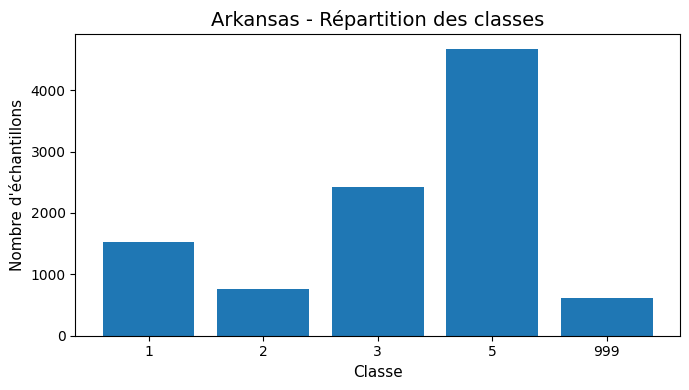


--- Arkansas : tableau récapitulatif ---


,missing_values,mean,std,min,max,n_unique
temp_mean_c,0,17.161923,0.798884,14.306910,18.895679,1126
precip_mm,0,1403.656826,84.963012,1096.874829,1681.006055,1126
dewpoint_c,0,11.550539,1.011363,8.926712,13.564185,1126
soil_ph,0,5.952030,0.313837,4.700000,7.400000,28
soil_oc,0,0.276700,0.155060,0.000000,4.500000,28
elevation_m,0,67.444600,46.337005,29.000000,658.000000,292
soil_texture,0,NaN,NaN,NaN,NaN,8
landform_class,0,NaN,NaN,NaN,NaN,10



--- Arkansas : moyennes par classe ---


,temp_mean_c,precip_mm,dewpoint_c,soil_ph,soil_oc,elevation_m
label,,,,,,
1,17.380013,1422.462005,11.847276,5.933311,0.229698,59.365309
2,16.952534,1412.616411,11.395688,5.964829,0.217454,62.678478
3,16.853423,1374.297384,11.078356,6.008791,0.297565,66.192324
5,17.310356,1412.857103,11.751446,5.987193,0.270857,57.487492
999,16.968570,1391.740513,11.340824,5.492208,0.428409,173.827922



--- Arkansas : écarts-types par classe ---


,temp_mean_c,precip_mm,dewpoint_c,soil_ph,soil_oc,elevation_m
label,,,,,,
1,0.782339,75.187827,1.010941,0.273797,0.091584,19.883766
2,0.812612,78.428135,0.986866,0.239407,0.053741,15.413709
3,0.694008,78.524817,0.840330,0.290763,0.165745,12.512032
5,0.739259,77.384141,0.976525,0.290269,0.139915,17.624654
999,1.114277,144.230186,1.178526,0.369492,0.273350,135.547908


In [207]:


df_ark = load_dataset(ARK_PATH, "Arkansas")
df_ark["label_name"] = df_ark["label"].map(label_mapping_ark)
df_ark = load_dataset(ARK_PATH, "Arkansas")



df_ark["label_name"] = df_ark["label"].map(label_mapping_ark)
df_ark["soil_texture_name"] = df_ark["soil_texture"].map(soil_texture_mapping)
df_ark["landform_name"] = df_ark["landform_class"].map(landform_mapping)


check_required_columns(df_ark, "Arkansas")
display(df_ark[["label", "label_name"]].drop_duplicates().sort_values("label"))


ark_class_counts = show_basic_info(df_ark, "Arkansas")
plot_class_distribution(df_ark, "Arkansas")
build_summary_table(df_ark, "Arkansas")
show_class_means_stds(df_ark, "Arkansas")

## Distributions globales

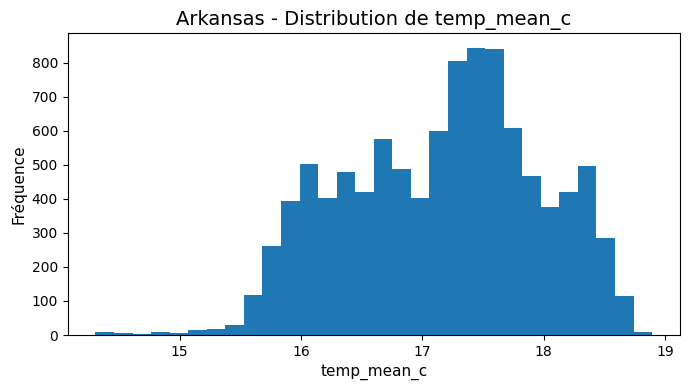

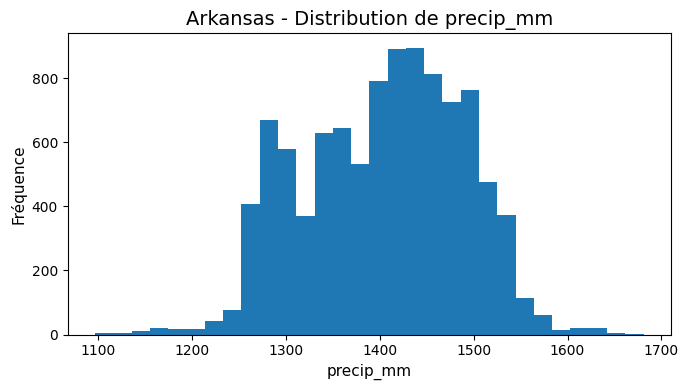

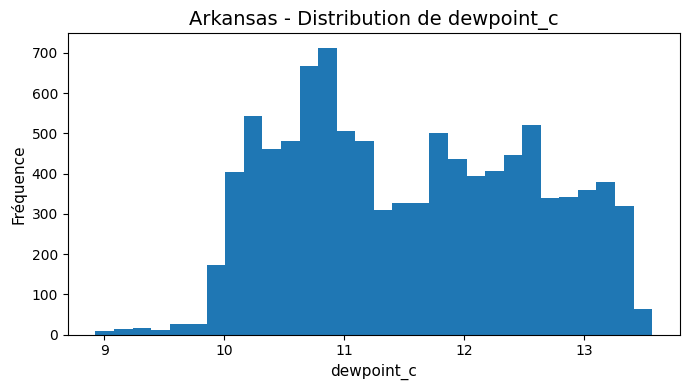

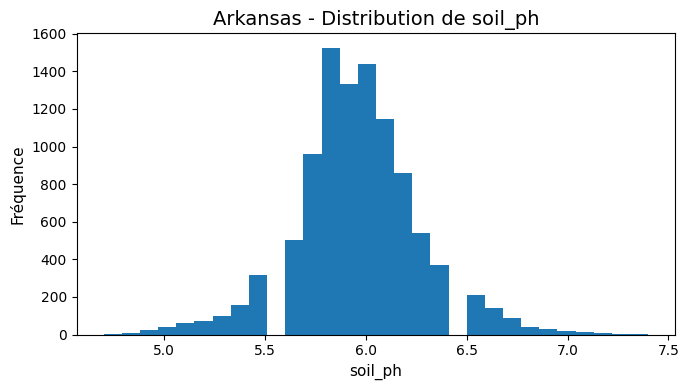

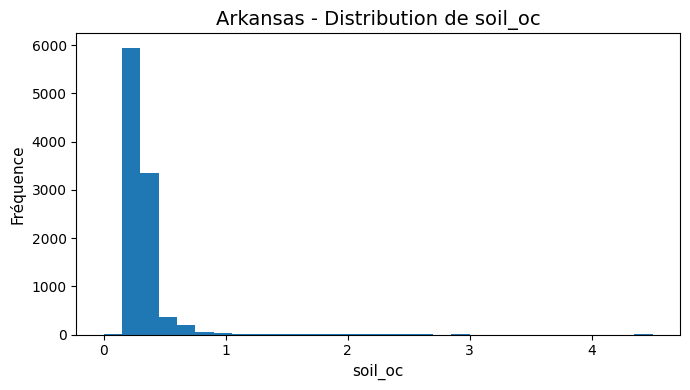

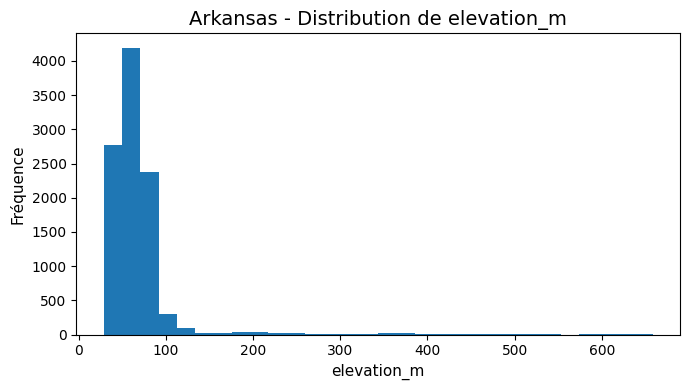

In [208]:
plot_histograms(df_ark, "Arkansas")

## Comparaison par classe en utilisant boxplots


<Figure size 900x480 with 0 Axes>

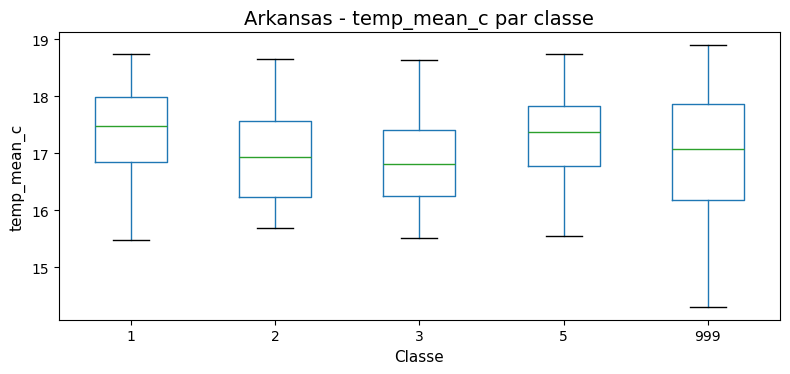

<Figure size 900x480 with 0 Axes>

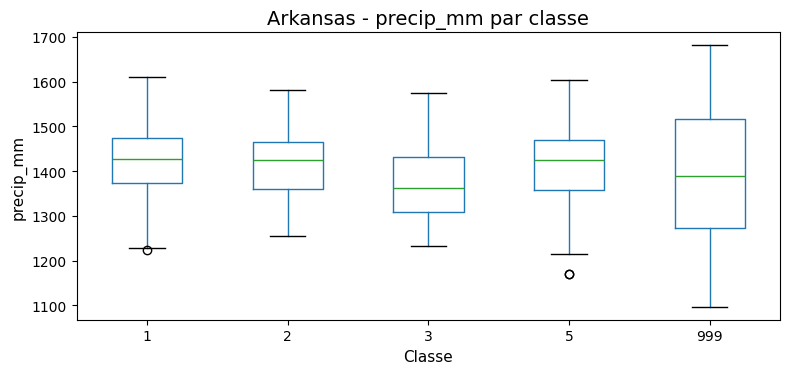

<Figure size 900x480 with 0 Axes>

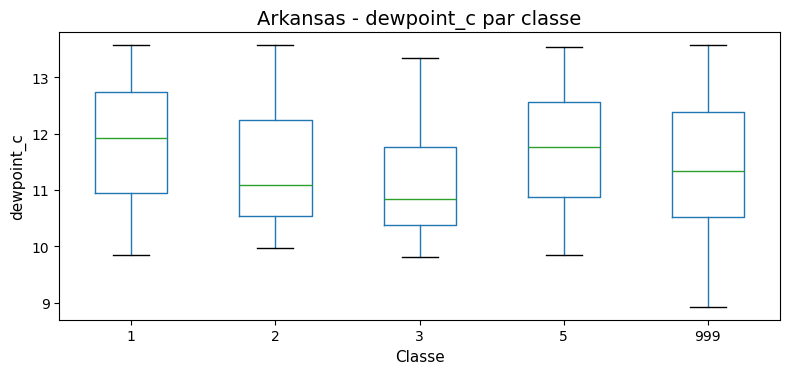

<Figure size 900x480 with 0 Axes>

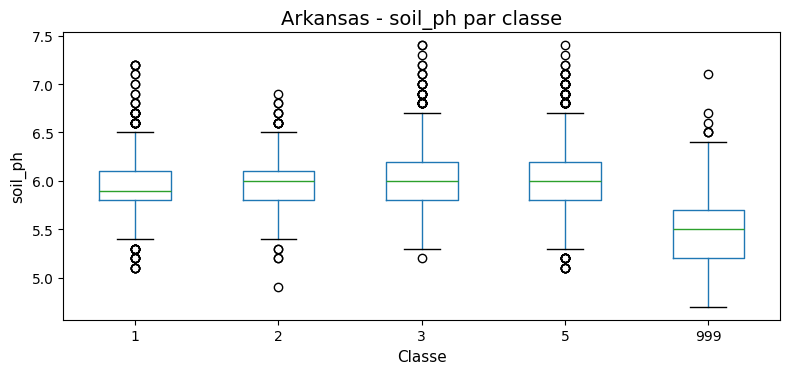

<Figure size 900x480 with 0 Axes>

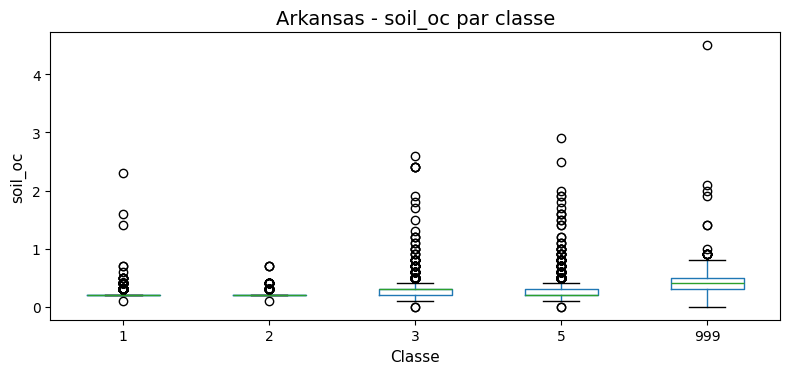

<Figure size 900x480 with 0 Axes>

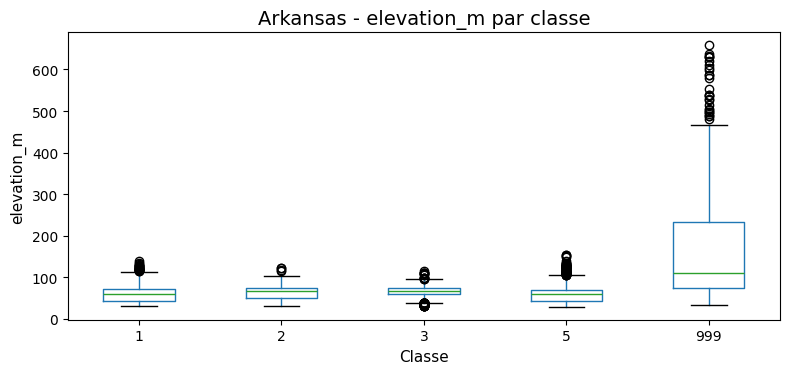

In [209]:
plot_boxplots_by_class(df_ark, "Arkansas")

### 3.3 Corrélation entre covariables numériques

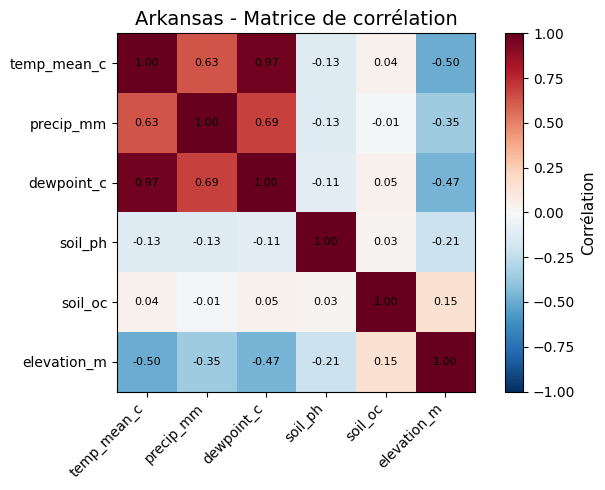

In [210]:
ark_corr = correlation_analysis(df_ark, "Arkansas")

### 3.4 Variables catégorielles


--- Arkansas : distribution de soil_texture ---


,count
soil_texture_name,
Clay,475
Clay loam,269
Loamy sand,1434
Sand,843
Sandy clay loam,1879
Sandy loam,4946
Silt,152
Silty clay,2



--- Arkansas : tableau croisé label_name x soil_texture_name ---


soil_texture_name,Clay,Clay loam,Loamy sand,Sand,Sandy clay loam,Sandy loam,Silt,Silty clay
label_name,,,,,,,,
Corn,12,9,126,76,298,972,28,1
Cotton,1,1,40,11,241,396,72,0
Others,0,3,15,14,299,284,1,0
Rice,153,96,367,318,288,1191,10,0
Soybeans,309,160,886,424,753,2103,41,1


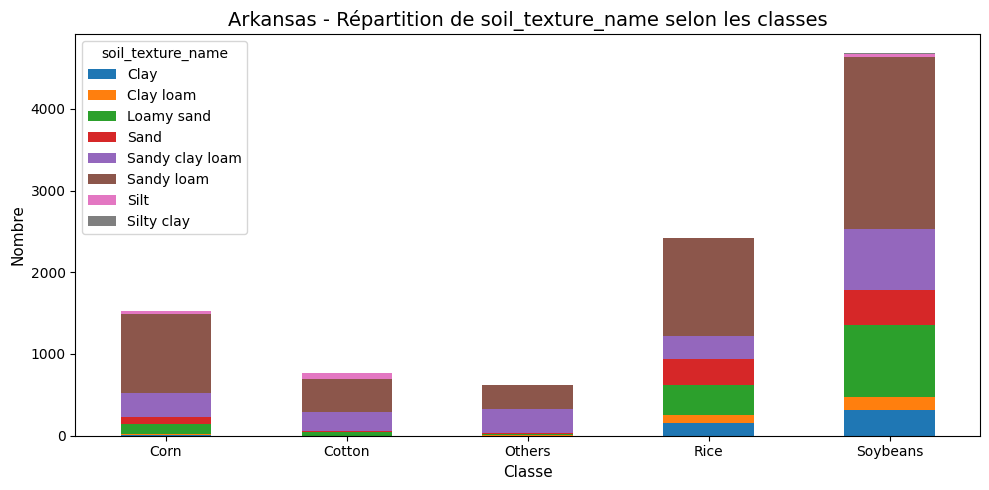


--- Arkansas : distribution de landform_class ---


,count
landform_name,
Lower slope,10
Lower slope (flat),5049
Lower slope (warm),880
Peak/ridge,2
Peak/ridge (warm),5
Upper slope,23
Upper slope (flat),2337
Upper slope (warm),598
Valley,1044



--- Arkansas : tableau croisé label_name x landform_name ---


landform_name,Lower slope,Lower slope (flat),Lower slope (warm),Peak/ridge,Peak/ridge (warm),Upper slope,Upper slope (flat),Upper slope (warm),Valley,Valley (narrow)
label_name,,,,,,,,,,
Corn,0,773,127,0,0,0,400,54,162,6
Cotton,0,383,45,0,0,0,227,22,83,2
Others,10,48,179,2,5,22,28,232,72,18
Rice,0,1395,119,0,0,0,572,62,265,10
Soybeans,0,2450,410,0,0,1,1110,228,462,16


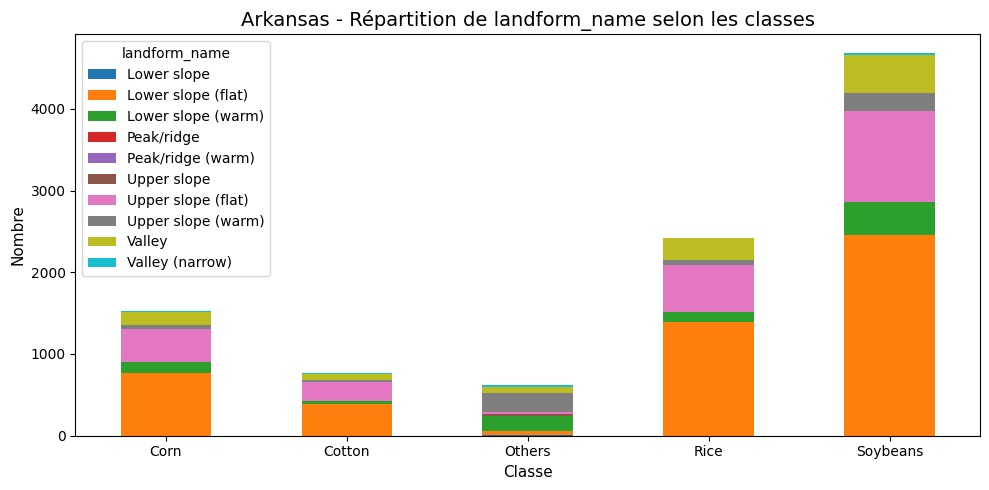

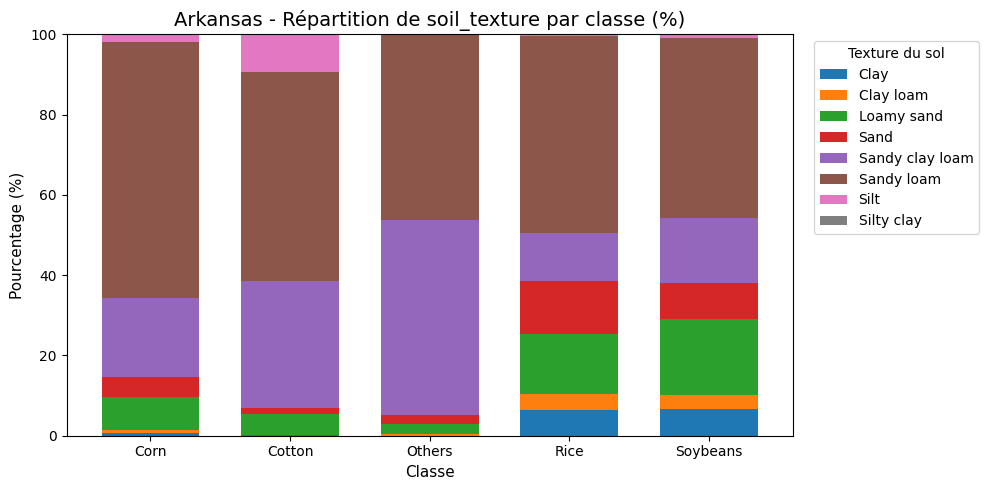

In [211]:
analyze_categorical_variables(df_ark, "Arkansas")
plot_soil_texture_percent(df_ark, "Arkansas")

### 3.5 Variables les plus informatives


--- Arkansas : ANOVA F-score ---


,feature,f_score,p_value
5,elevation_m,1356.952073,0.000000e+00
3,soil_ph,429.643526,0.000000e+00
4,soil_oc,244.523992,1.045322e-200
2,dewpoint_c,243.566785,5.958600e-200
0,temp_mean_c,195.236195,1.901090e-161
1,precip_mm,114.831410,6.702054e-96



--- Arkansas : Mutual Information ---


,feature,mutual_info
1,precip_mm,0.329005
2,dewpoint_c,0.322356
0,temp_mean_c,0.315988
5,elevation_m,0.174841
3,soil_ph,0.087552
4,soil_oc,0.072679
16,landform_class_21,0.034389
21,landform_class_34,0.024355
9,soil_texture_5.0,0.020259
10,soil_texture_7.0,0.018169


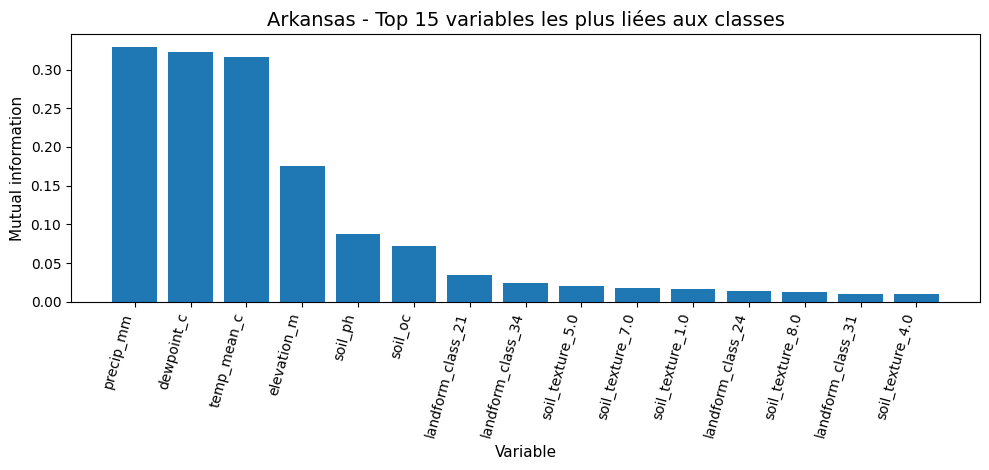

In [212]:
ark_anova, ark_mi = feature_importance_analysis(df_ark, "Arkansas")

## 4. Analyse California

CALIFORNIA — Chargement terminé
Dimensions : (10000, 369)
California: toutes les colonnes attendues sont présentes.

--- Aperçu général ---
Dimensions : (10000, 369)

--- Valeurs manquantes ---


,missing_values
label,0
temp_mean_c,0
precip_mm,0
dewpoint_c,0
soil_ph,0
soil_oc,0
elevation_m,0
soil_texture,0
landform_class,0



--- Répartition des classes ---


,count
label,
3,2037
36,974
69,2054
75,783
204,640
999,3512



--- Statistiques descriptives des covariables numériques ---


,count,mean,std,min,25%,50%,75%,max
temp_mean_c,10000.0,17.958491,3.601402,1.414248,16.759403,18.881301,19.877873,26.513014
precip_mm,10000.0,389.706029,180.021046,41.147228,278.464752,386.739458,495.991911,1754.183824
dewpoint_c,10000.0,4.356643,3.331204,-11.062462,4.056746,5.496073,6.340428,11.981764
soil_ph,10000.0,7.475290,0.403679,4.700000,7.300000,7.500000,7.700000,8.600000
soil_oc,10000.0,0.284190,0.192673,0.000000,0.200000,0.200000,0.300000,2.900000
elevation_m,10000.0,291.010800,540.172456,-107.000000,26.000000,71.000000,138.000000,3896.000000


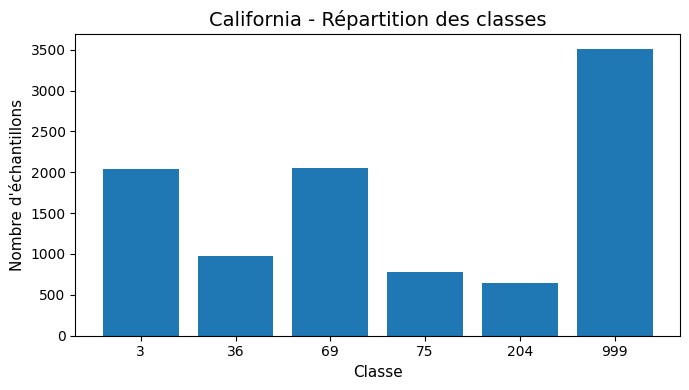


--- California : tableau récapitulatif ---


,missing_values,mean,std,min,max,n_unique
temp_mean_c,0,17.958491,3.601402,1.414248,26.513014,1860
precip_mm,0,389.706029,180.021046,41.147228,1754.183824,1860
dewpoint_c,0,4.356643,3.331204,-11.062462,11.981764,1860
soil_ph,0,7.475290,0.403679,4.700000,8.600000,39
soil_oc,0,0.284190,0.192673,0.000000,2.900000,27
elevation_m,0,291.010800,540.172456,-107.000000,3896.000000,1364
soil_texture,0,NaN,NaN,NaN,NaN,9
landform_class,0,NaN,NaN,NaN,NaN,12



--- California : moyennes par classe ---


,temp_mean_c,precip_mm,dewpoint_c,soil_ph,soil_oc,elevation_m
label,,,,,,
3,18.591375,517.594446,5.338867,7.327786,0.415022,29.548846
36,16.994980,325.232312,2.086615,7.448357,0.281828,583.579055
69,17.694483,356.287421,4.147938,7.512269,0.254674,339.215190
75,18.336557,390.528517,6.233208,7.563218,0.228352,100.408685
204,18.222072,400.670795,6.253194,7.554063,0.229063,103.448437
999,17.880710,350.773527,3.774569,7.512728,0.248719,410.004556



--- California : écarts-types par classe ---


,temp_mean_c,precip_mm,dewpoint_c,soil_ph,soil_oc,elevation_m
label,,,,,,
3,1.003723,118.374593,1.186080,0.238989,0.267272,116.081251
36,5.581655,193.391904,4.093362,0.347021,0.126411,666.218822
69,4.385551,172.518078,3.631854,0.366212,0.119036,527.653497
75,2.168811,132.661090,1.029698,0.357922,0.071256,84.911577
204,2.085871,133.952537,1.049541,0.377434,0.080096,96.457052
999,3.748663,190.737657,3.768237,0.496820,0.190619,663.790683


In [213]:
df_cal = load_dataset(CAL_PATH, "California")
check_required_columns(df_cal, "California")

cal_class_counts = show_basic_info(df_cal, "California")
plot_class_distribution(df_cal, "California")
build_summary_table(df_cal, "California")
show_class_means_stds(df_cal, "California")

### 4.1 Distributions globales

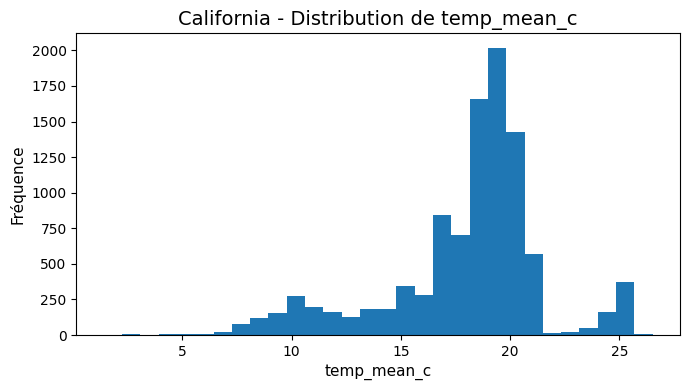

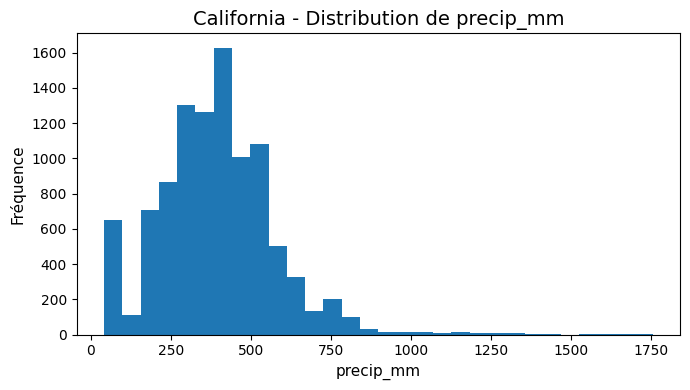

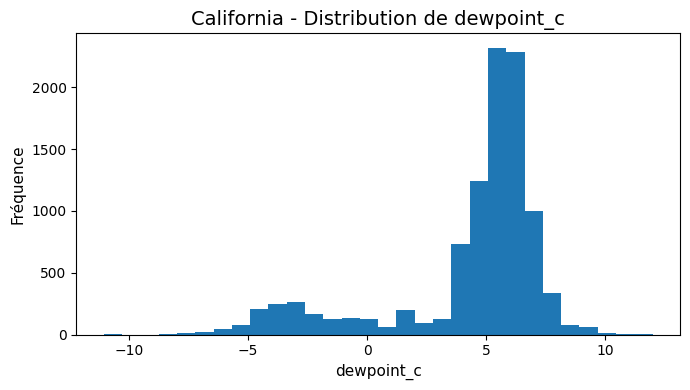

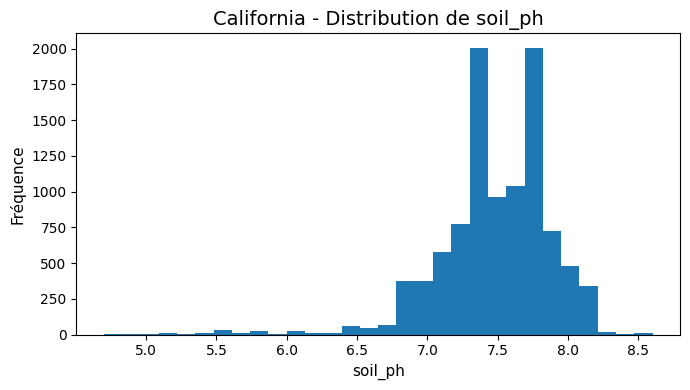

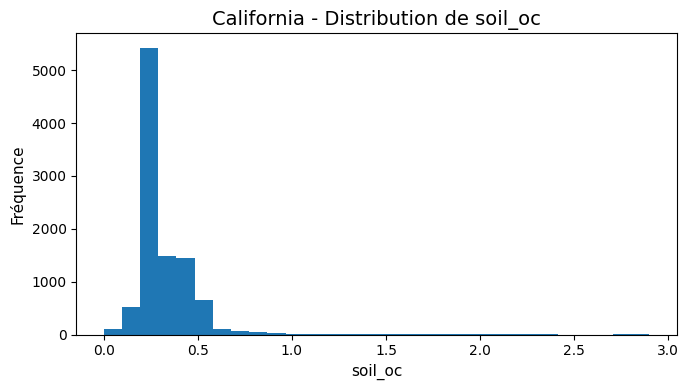

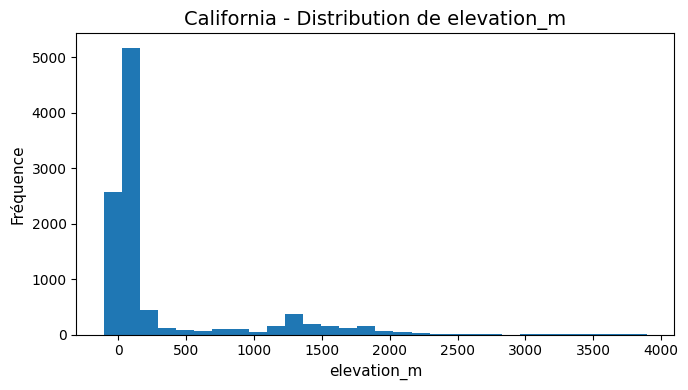

In [214]:
plot_histograms(df_cal, "California")

### 4.2 Comparaison par classe

<Figure size 900x480 with 0 Axes>

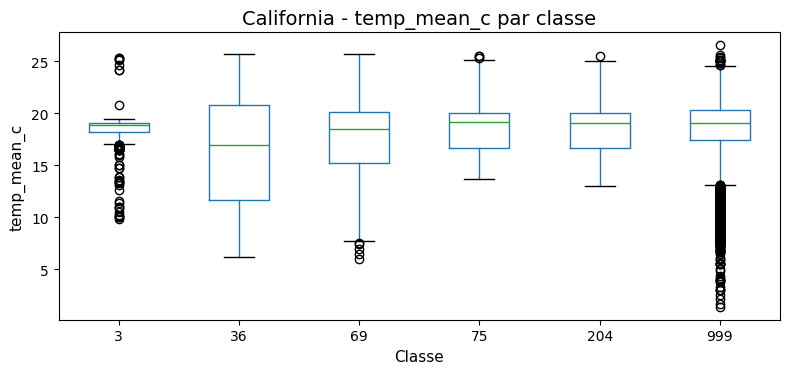

<Figure size 900x480 with 0 Axes>

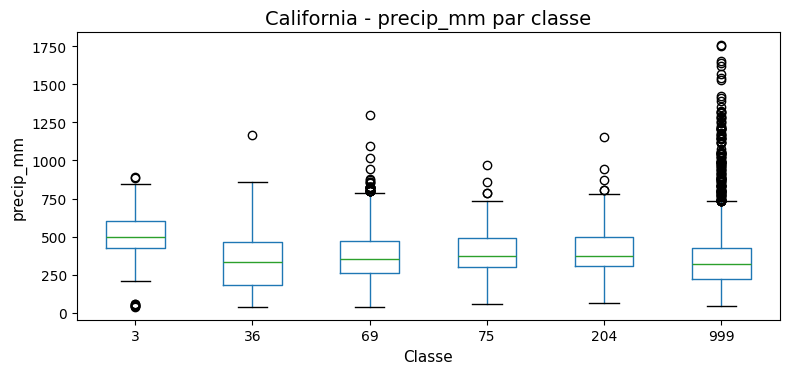

<Figure size 900x480 with 0 Axes>

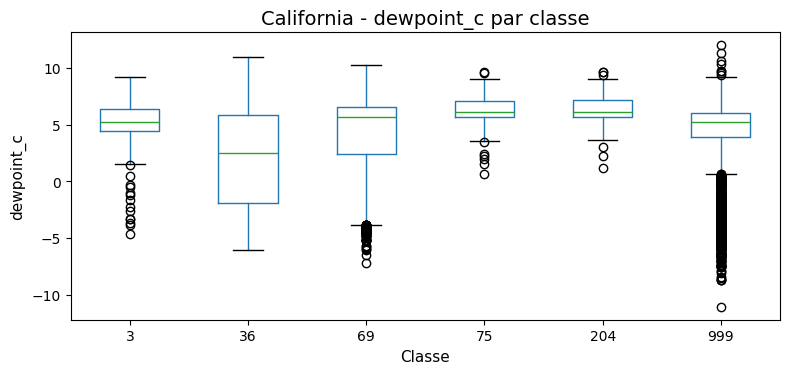

<Figure size 900x480 with 0 Axes>

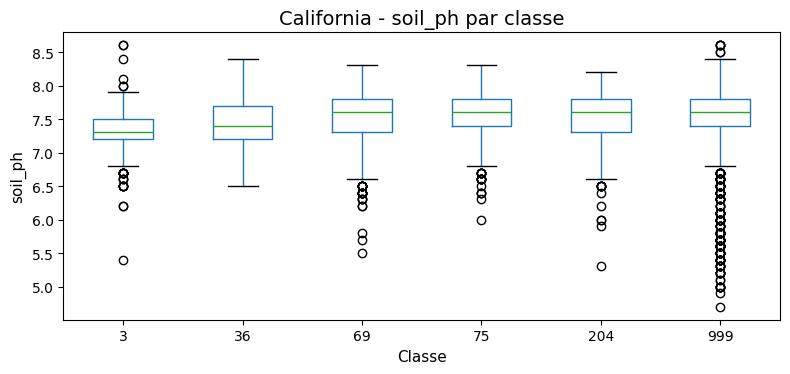

<Figure size 900x480 with 0 Axes>

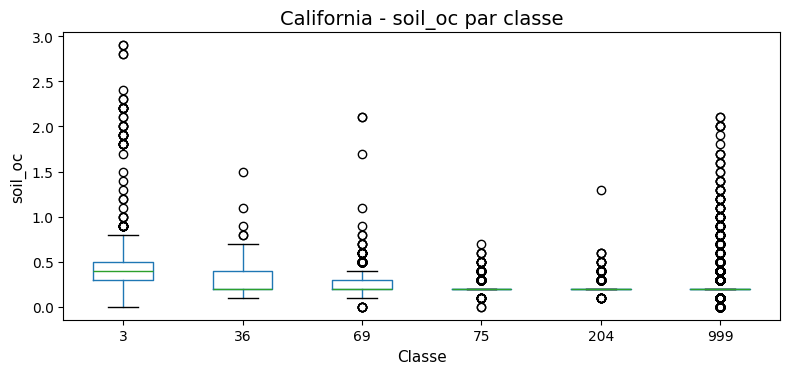

<Figure size 900x480 with 0 Axes>

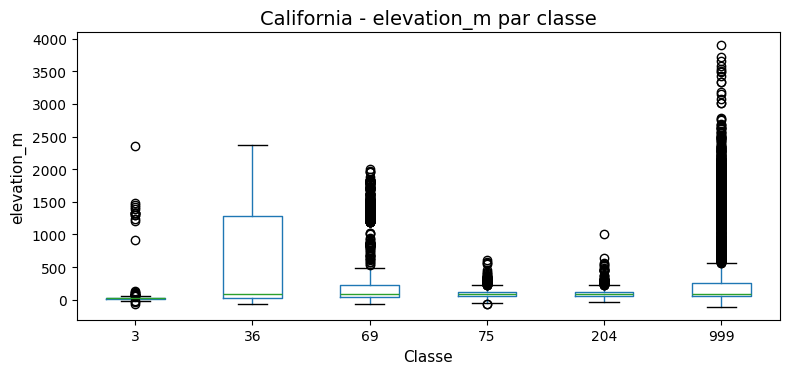

In [215]:
plot_boxplots_by_class(df_cal, "California")

### 4.3 Corrélation entre covariables numériques

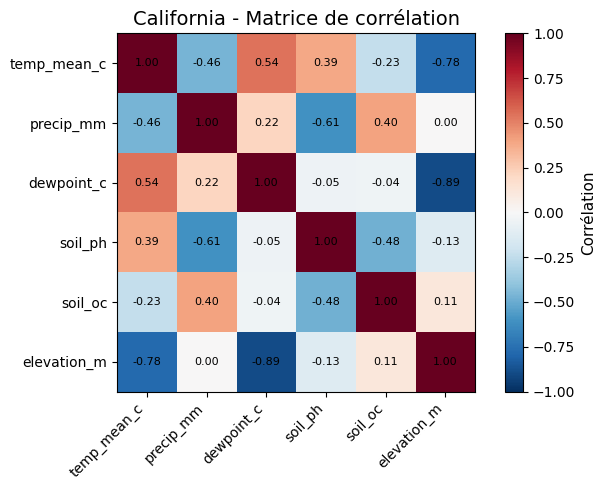

In [216]:
cal_corr = correlation_analysis(df_cal, "California")

### 4.4 Variables catégorielles


--- California : distribution de soil_texture ---


,count
soil_texture,
1.0,311
2.0,101
4.0,2433
5.0,55
6.0,88
7.0,6541
8.0,6
9.0,452
11.0,13



--- California : tableau croisé label x soil_texture ---


soil_texture,1.0,2.0,4.0,5.0,6.0,7.0,8.0,9.0,11.0
label,,,,,,,,,
3,303,99,1223,54,1,357,0,0,0
36,1,2,215,1,9,728,2,15,1
69,2,0,279,0,14,1731,2,26,0
75,0,0,56,0,8,717,0,2,0
204,0,0,64,0,4,569,0,3,0
999,5,0,596,0,52,2439,2,406,12


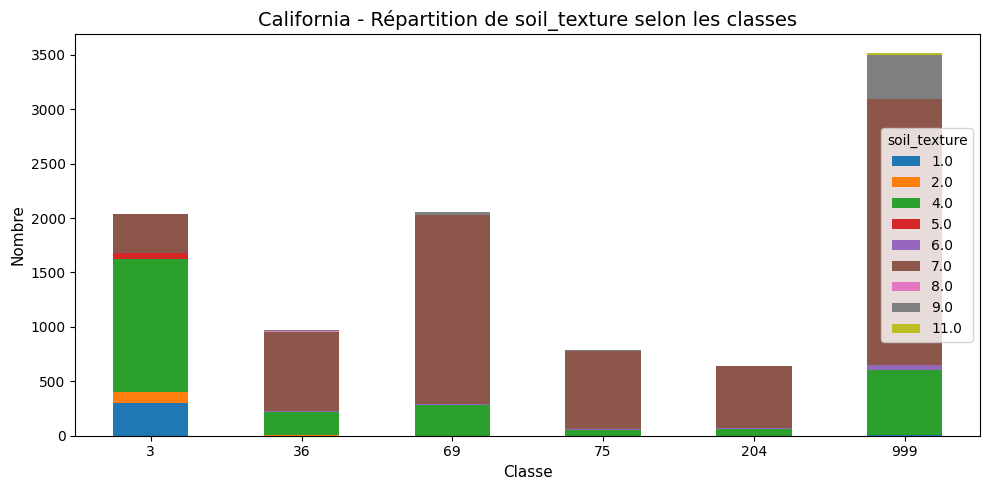


--- California : distribution de landform_class ---


,count
landform_class,
11,12
12,13
21,373
22,184
23,4
24,2812
31,497
32,235
33,2



--- California : tableau croisé label x landform_class ---


landform_class,11,12,21,22,23,24,31,32,33,34,41,42
label,,,,,,,,,,,,
3,0,0,5,1,0,653,5,2,0,1124,247,0
36,0,0,13,4,0,224,15,22,0,603,91,2
69,2,0,64,22,0,550,109,42,0,1107,155,3
75,0,0,51,5,0,245,67,8,0,339,68,0
204,0,0,49,5,0,183,60,4,0,286,52,1
999,10,13,191,147,4,957,241,157,2,1536,241,13


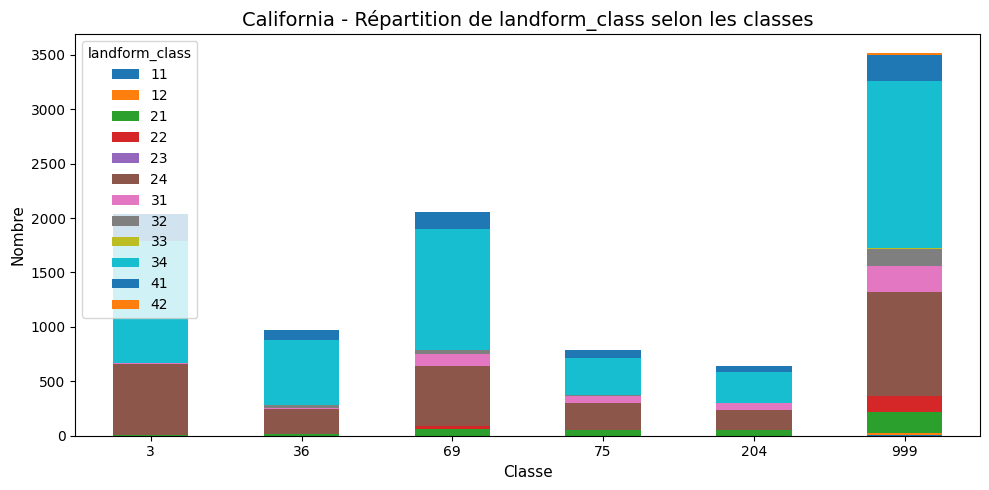

In [217]:
analyze_categorical_variables(df_cal, "California")

### 4.5 Variables les plus informatives


--- California : ANOVA F-score ---


,feature,f_score,p_value
1,precip_mm,322.831988,0.000000e+00
4,soil_oc,279.010712,3.065301e-280
2,dewpoint_c,272.750226,2.794818e-274
5,elevation_m,253.247059,1.308854e-255
3,soil_ph,80.102019,1.082297e-82
0,temp_mean_c,31.958244,2.015346e-32



--- California : Mutual Information ---


,feature,mutual_info
2,dewpoint_c,0.675196
0,temp_mean_c,0.662283
1,precip_mm,0.647078
5,elevation_m,0.400110
4,soil_oc,0.163950
11,soil_texture_7.0,0.147921
3,soil_ph,0.092721
8,soil_texture_4.0,0.073089
6,soil_texture_1.0,0.056007
13,soil_texture_9.0,0.024285


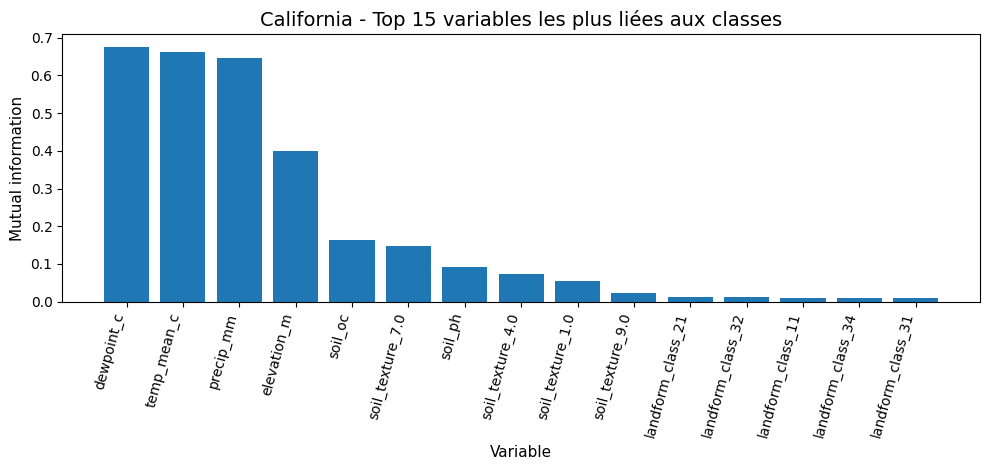

In [218]:
cal_anova, cal_mi = feature_importance_analysis(df_cal, "California")

##  Comparaison  Arkansas vs California


In [219]:
comparison_df = pd.DataFrame({
    "Arkansas_mean": df_ark[NUM_COLS].mean(),
    "California_mean": df_cal[NUM_COLS].mean(),
    "Arkansas_std": df_ark[NUM_COLS].std(),
    "California_std": df_cal[NUM_COLS].std()
})

display(comparison_df)

,Arkansas_mean,California_mean,Arkansas_std,California_std
temp_mean_c,17.161923,17.958491,0.798884,3.601402
precip_mm,1403.656826,389.706029,84.963012,180.021046
dewpoint_c,11.550539,4.356643,1.011363,3.331204
soil_ph,5.952030,7.475290,0.313837,0.403679
soil_oc,0.276700,0.284190,0.155060,0.192673
elevation_m,67.444600,291.010800,46.337005,540.172456


In [220]:
 # sauvegarde les tableaux de scores dans des CSV
ark_anova.to_csv("arkansas_anova.csv", index=False)
ark_mi.to_csv("arkansas_mutual_info.csv", index=False)
cal_anova.to_csv("california_anova.csv", index=False)
cal_mi.to_csv("california_mutual_info.csv", index=False)

print("Fichiers CSV exportés.")

Fichiers CSV exportés.
